# Cardiovascular disease prediction
- Said Abolhassan Razavi
## Introduction
Cardiovascular diseases (CVDs) are among the leading causes of mortality worldwide, and early detection is essential to improve patient outcomes. However, diagnosing CVD typically requires medical expertise, multiple clinical examinations, and sometimes expensive procedures. In this project, we aim to build a machine learning model capable of predicting the presence of cardiovascular disease based solely on simple, non-invasive measurements such as age, blood pressure, cholesterol level, and lifestyle factors.

The dataset used in this project is a public cardiovascular dataset from [Kaggle](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset/data) containing 70,000 patient records with 11 features describing physical characteristics (age, height, weight), examination results (systolic and diastolic blood pressure, cholesterol, glucose), and subjective lifestyle indicators (smoking, alcohol use, physical activity). The target variable, cardio, indicates whether the patient has been diagnosed with cardiovascular disease (1) or not (0).


Our objective is to explore this dataset, clean and preprocess the data, and build predictive models capable of identifying patterns associated with cardiovascular disease. We will experiment with several machine learning algorithms and evaluate their performance using common classification metrics such as accuracy, F1-score, and ROC-AUC. Finally, we compare our approach to existing state-of-the-art solutions available for this dataset and discuss the strengths and limitations of our model.

Through this project, we aim to gain practical experience with supervised learning on tabular medical data, understand the impact of preprocessing choices on model performance, and analyze which features are most important in predicting cardiovascular disease.


https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset/data

| Feature | Category | Column | Type / Notes |
|---|---:|---|---|
| Age | Objective Feature | age | int (days) |
| Height | Objective Feature | height | int (cm) |
| Weight | Objective Feature | weight | float (kg) |
| Gender | Objective Feature | gender | categorical code |
| Systolic blood pressure | Examination Feature | ap_hi | int |
| Diastolic blood pressure | Examination Feature | ap_lo | int |
| Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |
| Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal |
| Smoking | Subjective Feature | smoke | binary |
| Alcohol intake | Subjective Feature | alco | binary |
| Physical activity | Subjective Feature | active | binary |
| Presence or absence of cardiovascular disease | Target Variable | cardio | binary |

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from matplotlib.colors import ListedColormap
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
import kagglehub
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn import svm
from sklearn.model_selection import GridSearchCV



# Downloading the dataset from Kaggle
path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")

print("Path to dataset files:", path)

# Load a CSV file from the dataset into a pandas DataFrame
data = pd.read_csv(f"{path}/cardio_train.csv", sep=";")

warnings.filterwarnings("ignore")

/home/daryl/master1_info_ds/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/daryl/.cache/kagglehub/datasets/sulianova/cardiovascular-disease-dataset/versions/1


In [2]:
data.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Basic info
print("Shape:", data.shape)
print("\nDtypes:\n", data.dtypes)
print("\nMissing values:\n", data.isna().sum())

# Duplicates
dups = data.duplicated().sum()
print("\nDuplicate rows:", dups)

Shape: (70000, 13)

Dtypes:
 id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

Missing values:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows: 0


There are 70000 entries of patient records and we can assume that there is no missing values and no duplicate rows.

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [5]:
#dropping the id column as it is not useful for analysis
data.drop("id", axis=1, inplace=True)

## Exploration, Preprocessing

### Analyzing the features' distribution
#### Age
The age is given in days values; let's start by converting it to years

In [6]:
data["age"] = (data["age"] / 365).astype(int)
data["age"].describe().T

count    70000.000000
mean        52.840671
std          6.766774
min         29.000000
25%         48.000000
50%         53.000000
75%         58.000000
max         64.000000
Name: age, dtype: float64

Then let's take a look at the age distribution

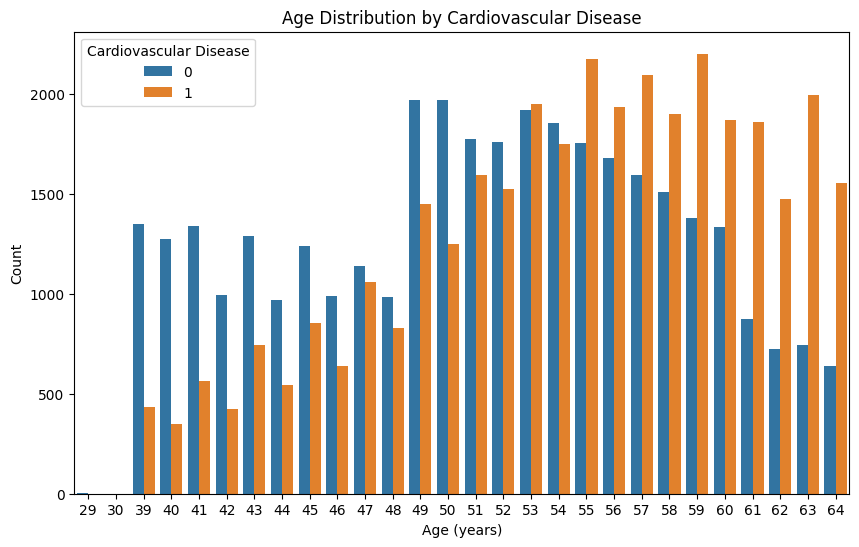

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(x="age", data=data, hue="cardio")
plt.title("Age Distribution by Cardiovascular Disease")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.legend(title="Cardiovascular Disease")
plt.show()

We can see that, the people with age greater than 53 are more likely to have cardiovascular disease (CVD). But that age grouping (under 53 vs over 53) is too broad and doesn't show the variations within the two groups.

To have a better view of the distribution , let's categorize ages in 10-years intervals.

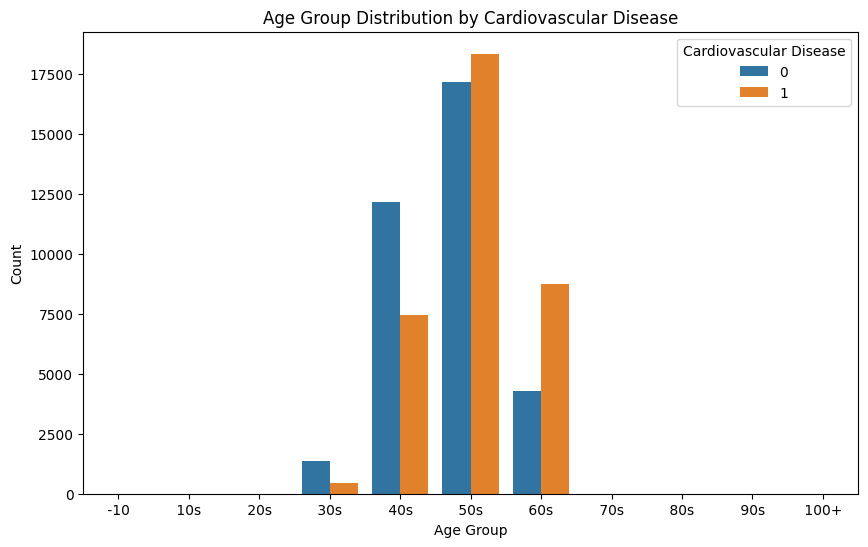

In [8]:
def categorize_age(age):
    if age < 10:
        return " -10 "
    elif age > 100:
        return " 100+ "
    else:
        return f" {age // 10}0s "

# Apply categorization and plot with matching order labels
data["age_group"] = data["age"].apply(categorize_age)
order = [
    " -10 ",
    " 10s ",
    " 20s ",
    " 30s ",
    " 40s ",
    " 50s ",
    " 60s ",
    " 70s ",
    " 80s ",
    " 90s ",
    " 100+ ",
]


plt.figure(figsize=(10, 6))
sns.countplot(x="age_group", data=data, hue="cardio", order=order)
plt.title("Age Group Distribution by Cardiovascular Disease")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Cardiovascular Disease")
plt.show()


This graph implies that 50s and 60s ages are more prone to be affected by CVD than 30s and 40s. The other age groups are not represented in the dataset.

In [9]:
# One-hot encode age groups to make them numeric for modeling
age_group_dummies = pd.get_dummies(data["age_group"].str.strip(), prefix="age_group")
data = pd.concat([data.drop(columns=["age_group"]), age_group_dummies], axis=1)


#### Gender


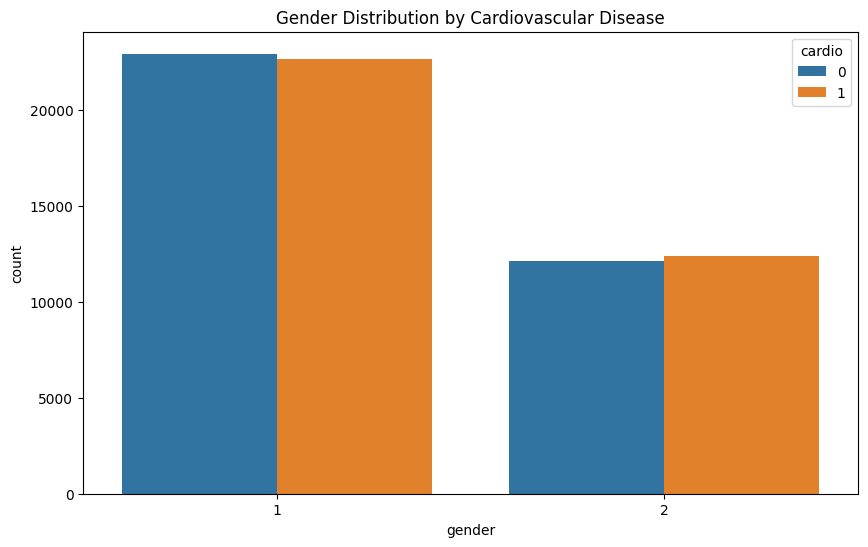

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(x="gender", data=data, hue="cardio")
plt.title("Gender Distribution by Cardiovascular Disease")
plt.show()

In this dataset, the gender is codified (1 or 2) and we don't know which one is female or male.

The graph shows that the distribution of CVD is balanced per gender but "gender 1" is almost twice "gender 2". We might have to consider oversampling "gender 2" to avoid bias.

#### Height, Weight

The height is given in cm and we'll start by converting it in usual measure (meter)

In [11]:
data["height"] = data["height"] / 100.0 
data[["height", "weight"]].describe().T

,count,mean,std,min,25%,50%,75%,max
height,70000.0,1.643592,0.082101,0.55,1.59,1.65,1.7,2.5
weight,70000.0,74.205690,14.395757,10.00,65.00,72.00,82.0,200.0


We will associate the height and weight by creating a new feature : the body mass index.

The body mass index (BMI) is calculated using the formula: **BMI = weight (kg) / height² (m²)**

In [12]:
data["bmi"] = data["weight"] / ((data["height"] / 100) ** 2)


#### Blood pressures (ap_hi, ap_low)

In [13]:
data[["ap_lo", "ap_hi"]].describe().T   

,count,mean,std,min,25%,50%,75%,max
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0


In [14]:
# removing rows with  negative blood pressure readings
data = data[(data["ap_hi"] > 0) & (data["ap_lo"] > 0)]

# removing extreme 1% outliers
alpha = 0.01
for col in ['ap_hi', 'ap_lo']:
    q_low = data[col].quantile(alpha)
    q_high = data[col].quantile(1 - alpha)
    before_rows = data.shape[0]
    data = data[(data[col] >= q_low) & (data[col] <= q_high)]
    after_rows = data.shape[0]
    print(f"Removed {before_rows - after_rows} outliers from '{col}'")

data[["ap_lo", "ap_hi"]].describe().T   


Removed 673 outliers from 'ap_hi'
Removed 365 outliers from 'ap_lo'


,count,mean,std,min,25%,50%,75%,max
ap_lo,68933.0,90.208536,90.090973,60.0,80.0,80.0,90.0,1000.0
ap_hi,68933.0,126.672566,16.159131,90.0,120.0,120.0,140.0,180.0


Another feature can be deduced from the blood pressure :  the pulse pressure.

**pulse_pressure = ap_hi - ap_lo**

In [15]:
data["pulse_pressure"] = data["ap_hi"] - data["ap_lo"]
data["pulse_pressure"].describe().T

count    68933.000000
mean        36.464030
std         87.858214
min       -880.000000
25%         40.000000
50%         40.000000
75%         50.000000
max        120.000000
Name: pulse_pressure, dtype: float64

In [16]:
# removing pulse pressure negative or zero
data = data[data["pulse_pressure"] > 0]
data.describe().T


,count,mean,std,min,25%,50%,75%,max
age,68213.0,52.824315,6.769693,29.000000,48.000000,53.000000,58.000000,6.400000e+01
gender,68213.0,1.348599,0.476530,1.000000,1.000000,1.000000,2.000000,2.000000e+00
height,68213.0,1.643720,0.081761,0.550000,1.590000,1.650000,1.700000,2.500000e+00
weight,68213.0,74.100515,14.287812,11.000000,65.000000,72.000000,82.000000,2.000000e+02
ap_hi,68213.0,126.444930,15.969214,90.000000,120.000000,120.000000,140.000000,1.800000e+02
ap_lo,68213.0,81.272016,9.168994,60.000000,80.000000,80.000000,90.000000,1.500000e+02
cholesterol,68213.0,1.363333,0.678143,1.000000,1.000000,1.000000,1.000000,3.000000e+00
gluc,68213.0,1.225148,0.571260,1.000000,1.000000,1.000000,1.000000,3.000000e+00
smoke,68213.0,0.087681,0.282833,0.000000,0.000000,0.000000,0.000000,1.000000e+00
alco,68213.0,0.053098,0.224231,0.000000,0.000000,0.000000,0.000000,1.000000e+00


cardio,0,1
cholesterol,,
1,0.57,0.43
2,0.40,0.60
3,0.24,0.76


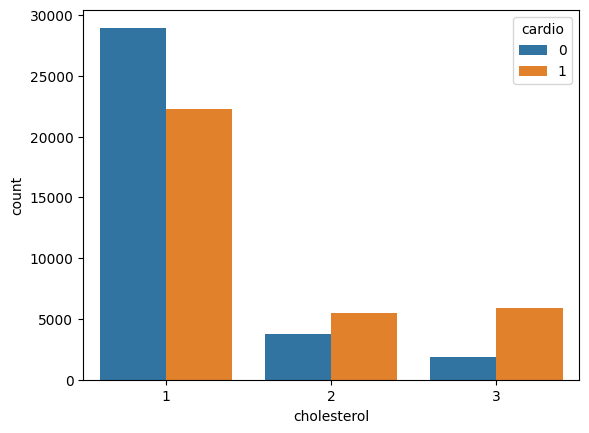

cardio,0,1
gluc,,
1,0.53,0.47
2,0.41,0.59
3,0.38,0.62


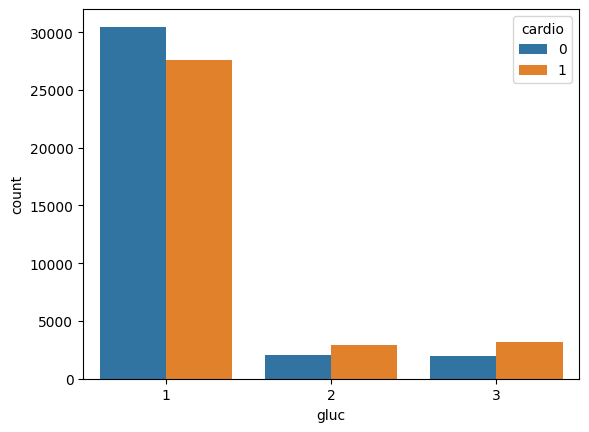

cardio,0,1
smoke,,
0,0.50,0.50
1,0.53,0.47


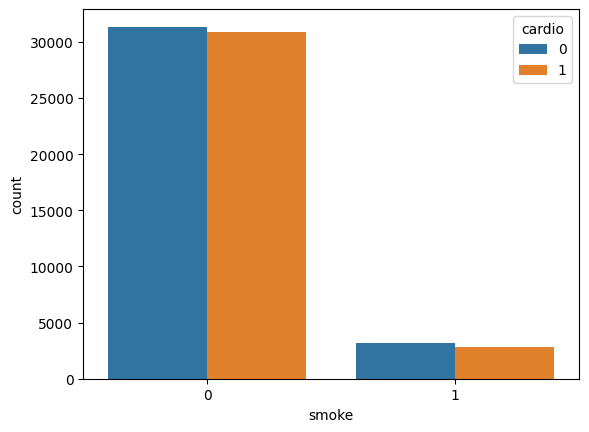

cardio,0,1
alco,,
0,0.51,0.49
1,0.53,0.47


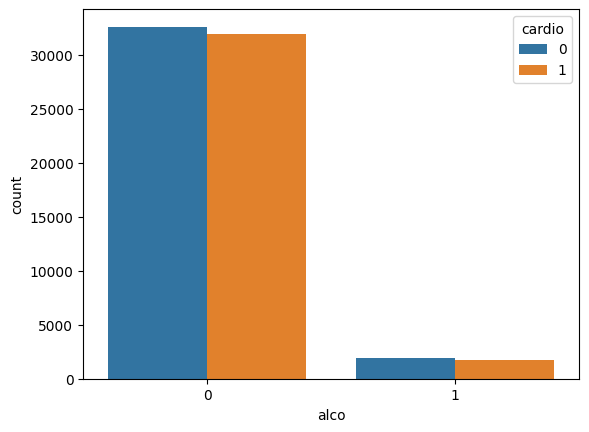

cardio,0,1
active,,
0,0.47,0.53
1,0.52,0.48


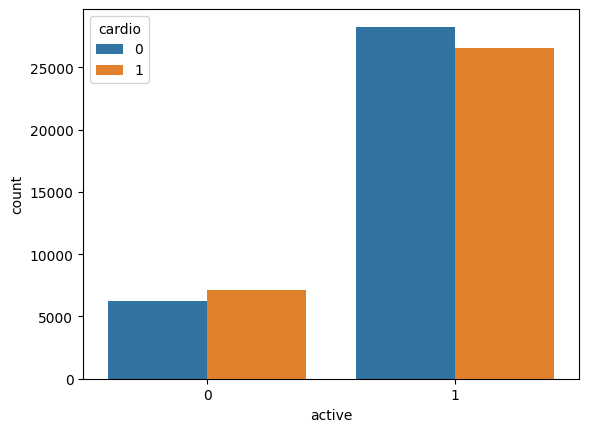

In [17]:
# Categorical counts vs target
cols = ['cholesterol','gluc','smoke','alco','active']
for c in cols:
    display(pd.crosstab(data[c], data['cardio'], normalize='index').round(2))
    sns.countplot(data=data, x=c, hue='cardio')
    plt.show()
    

#### Cholesterol (cholesterol), Glucose (gluc), Smoking(smoke) , Alcohol intake (alco), Physical activity (active)

From the graphs, people with "above normal" and "well above normal" levels of cholesterol and glucose show a higher prevalence of CVD.

Interestingly, this dataset suggests that smoking and alcohol intake do not significantly correlate with cardiovascular disease presence.

However, physical activity does appear to be a protective factor, as the proportion of people with CVD is higher among those who are physically inactive.



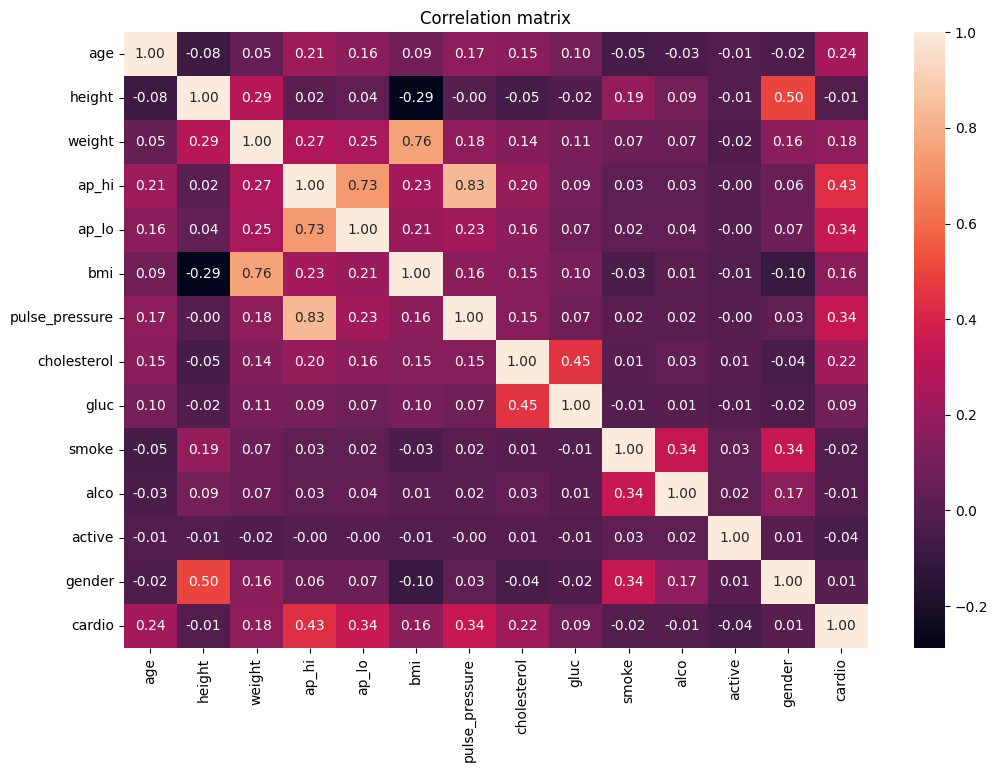

In [18]:
data_features = data.drop("cardio", axis=1)
data_target = data["cardio"]
numerical_features = ["age", "height", "weight", "ap_hi", "ap_lo", "bmi", "pulse_pressure"]
categorical_features = ['cholesterol','gluc','smoke','alco','active','gender']
plt.figure(figsize=(12,8))
sns.heatmap(data[numerical_features + categorical_features + ["cardio"]].corr(), annot=True, fmt=".2f")
plt.title('Correlation matrix')
plt.show()


The most significant features for the target "cardio" are : ap_hi, ap_lo, pulse_pressure, age, cholesterol

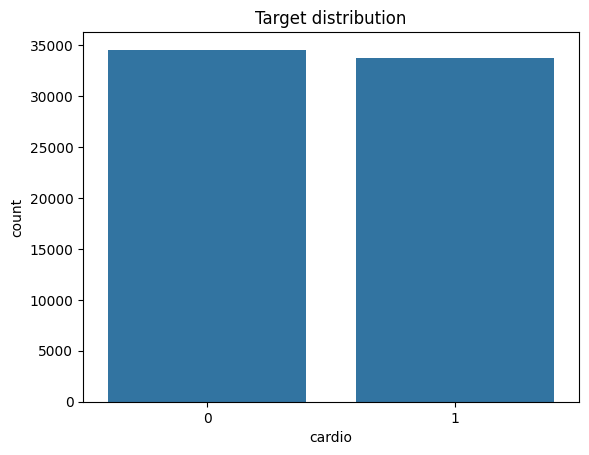

In [19]:
#Target distribution
sns.countplot(data=data, x='cardio')
plt.title('Target distribution')
plt.show()


In [20]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,68213.0,52.824315,6.769693,29.000000,48.000000,53.000000,58.000000,6.400000e+01
gender,68213.0,1.348599,0.476530,1.000000,1.000000,1.000000,2.000000,2.000000e+00
height,68213.0,1.643720,0.081761,0.550000,1.590000,1.650000,1.700000,2.500000e+00
weight,68213.0,74.100515,14.287812,11.000000,65.000000,72.000000,82.000000,2.000000e+02
ap_hi,68213.0,126.444930,15.969214,90.000000,120.000000,120.000000,140.000000,1.800000e+02
ap_lo,68213.0,81.272016,9.168994,60.000000,80.000000,80.000000,90.000000,1.500000e+02
cholesterol,68213.0,1.363333,0.678143,1.000000,1.000000,1.000000,1.000000,3.000000e+00
gluc,68213.0,1.225148,0.571260,1.000000,1.000000,1.000000,1.000000,3.000000e+00
smoke,68213.0,0.087681,0.282833,0.000000,0.000000,0.000000,0.000000,1.000000e+00
alco,68213.0,0.053098,0.224231,0.000000,0.000000,0.000000,0.000000,1.000000e+00


In [21]:
data.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_group_20s,age_group_30s,age_group_40s,age_group_50s,age_group_60s,bmi,pulse_pressure
0,50,2,1.68,62.0,110,80,1,1,0,0,1,0,False,False,False,True,False,219671.201814,30
1,55,1,1.56,85.0,140,90,3,1,0,0,1,1,False,False,False,True,False,349276.791584,50
2,51,1,1.65,64.0,130,70,3,1,0,0,0,1,False,False,False,True,False,235078.053260,60
3,48,2,1.69,82.0,150,100,1,1,0,0,1,1,False,False,True,False,False,287104.793250,50
4,47,1,1.56,56.0,100,60,1,1,0,0,0,0,False,False,True,False,False,230111.768573,40


After the cleaning, we now have a dataset of 68213 patient records with 14 features.

### Training

In [22]:
X = data_features
y = data_target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((54570, 18), (13643, 18), (54570,), (13643,))

In [23]:
models = {
    "logistic_regression": sklearn.linear_model.LogisticRegression(),
    "random_forest": sklearn.ensemble.RandomForestClassifier(),
    "naive_bayes": sklearn.naive_bayes.GaussianNB(),
    "knn": sklearn.neighbors.KNeighborsClassifier()
}


results = []

scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Store results
    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    })
    
    print(f"{model_name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

# Convert to DataFrame
results = pd.DataFrame(results)
print("\nInitial Model Comparison:")
print(results)

logistic_regression Accuracy: 0.7248
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6907
           1       0.75      0.66      0.70      6736

    accuracy                           0.72     13643
   macro avg       0.73      0.72      0.72     13643
weighted avg       0.73      0.72      0.72     13643

random_forest Accuracy: 0.7076
              precision    recall  f1-score   support

           0       0.71      0.72      0.71      6907
           1       0.71      0.69      0.70      6736

    accuracy                           0.71     13643
   macro avg       0.71      0.71      0.71     13643
weighted avg       0.71      0.71      0.71     13643

naive_bayes Accuracy: 0.5055
              precision    recall  f1-score   support

           0       0.73      0.04      0.07      6907
           1       0.50      0.99      0.66      6736

    accuracy                           0.51     13643
   macro avg       0.61      0.

The most promising models are :  logistic regression, random forest and knn

In [24]:
results = pd.DataFrame(columns=["model", "accuracy", "recall", "f1_score", "roc_auc"])

# training logistic regression model
models["logistic_regression"] = sklearn.linear_model.LogisticRegression(max_iter=10000)
log_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs"]
}
log_grid = GridSearchCV(
    estimator=models["logistic_regression"],
    param_grid=log_param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
log_grid.fit(X_train_scaled, y_train)
print("Logistic Regression Model Evaluation:")
best_log = log_grid.best_estimator_
best_log.fit(X_train_scaled, y_train)
y_pred = best_log.predict(X_test_scaled)
y_proba = best_log.predict_proba(X_test_scaled)[:, 1]

log_row = {
    "model": "logistic_regression_tuned",
    "accuracy": accuracy_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}
results = pd.concat([results, pd.DataFrame([log_row])], ignore_index=True)
print("Accuracy: ", log_row["accuracy"])
print(classification_report(y_test, y_pred))
print("Best params:", log_grid.best_params_)

Fitting 10 folds for each of 8 candidates, totalling 80 fits
Logistic Regression Model Evaluation:
Accuracy:  0.7259400425126439
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6907
           1       0.75      0.67      0.71      6736

    accuracy                           0.73     13643
   macro avg       0.73      0.73      0.72     13643
weighted avg       0.73      0.73      0.72     13643

Best params: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}


In [25]:
# training random forest
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
rf_grid = GridSearchCV(
    estimator=models['random_forest'],
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Random Forest Model Evaluation:")
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

rf_row = {
    "model": "random_forest_tuned",
    "accuracy": accuracy_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}
results = pd.concat([results, pd.DataFrame([rf_row])], ignore_index=True)
print("Accuracy: ", rf_row["accuracy"])
print(classification_report(y_test, y_pred))
print("Best params:", rf_grid.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Random Forest Model Evaluation:
Accuracy:  0.7334897016785165
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6907
           1       0.76      0.68      0.72      6736

    accuracy                           0.73     13643
   macro avg       0.74      0.73      0.73     13643
weighted avg       0.74      0.73      0.73     13643

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [26]:
# training knn
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]   # 1 = Manhattan, 2 = Euclidean
}

knn_grid = GridSearchCV(
    estimator=models['knn'],
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_

print("K-Nearest Neighbors Model Evaluation:")
best_knn.fit(X_train_scaled, y_train)
y_pred = best_knn.predict(X_test_scaled)
y_proba = best_knn.predict_proba(X_test_scaled)[:, 1]

knn_row = {
    "model": "knn_tuned",
    "accuracy": accuracy_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}
results = pd.concat([results, pd.DataFrame([knn_row])], ignore_index=True)
print("Accuracy: ", knn_row["accuracy"])
print(classification_report(y_test, y_pred))
print("Best params:", knn_grid.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
K-Nearest Neighbors Model Evaluation:
Accuracy:  0.7185369786703805
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      6907
           1       0.73      0.69      0.71      6736

    accuracy                           0.72     13643
   macro avg       0.72      0.72      0.72     13643
weighted avg       0.72      0.72      0.72     13643

Best params: {'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}


## Evaluation

In [27]:
# View aggregated results from all models
results.round(4)

,model,accuracy,recall,f1_score,roc_auc
0,logistic_regression_tuned,0.7259,0.6688,0.7067,0.7917
1,random_forest_tuned,0.7335,0.6796,0.7158,0.8018
2,knn_tuned,0.7185,0.6882,0.7071,0.7695


### Best Model Selection

Based on the evaluation metrics, let's identify the best performing model.

In [28]:
# Summary of best models
print("=" * 70)
print("BEST MODELS BY METRIC")
print("=" * 70)

for metric in ['accuracy', 'recall', 'f1_score', 'roc_auc']:
    best_idx = results[metric].idxmax()
    best_model = results.loc[best_idx]
    print(f"\nBest {metric.upper()}: {best_model['model']}")
    print(f"  Value: {best_model[metric]:.4f}")

print("\n" + "=" * 70)
print("OVERALL RESULTS SUMMARY")
print("=" * 70)
print(results.sort_values('roc_auc', ascending=False).to_string(index=False))

# Identify best overall model (using ROC-AUC as primary metric)
best_overall_idx = results['roc_auc'].idxmax()
best_overall = results.loc[best_overall_idx]
print(f"\n{'=' * 70}")
print(f"BEST OVERALL MODEL: {best_overall['model'].upper()}")
print(f"  Accuracy: {best_overall['accuracy']:.4f}")
print(f"  Recall: {best_overall['recall']:.4f}")
print(f"  F1-Score: {best_overall['f1_score']:.4f}")
print(f"  ROC-AUC: {best_overall['roc_auc']:.4f}")
print("=" * 70)

BEST MODELS BY METRIC

Best ACCURACY: random_forest_tuned
  Value: 0.7335

Best RECALL: knn_tuned
  Value: 0.6882

Best F1_SCORE: random_forest_tuned
  Value: 0.7158

Best ROC_AUC: random_forest_tuned
  Value: 0.8018

OVERALL RESULTS SUMMARY
                    model  accuracy   recall  f1_score  roc_auc
      random_forest_tuned  0.733490 0.679632  0.715760 0.801778
logistic_regression_tuned  0.725940 0.668795  0.706722 0.791739
                knn_tuned  0.718537 0.688242  0.707138 0.769504

BEST OVERALL MODEL: RANDOM_FOREST_TUNED
  Accuracy: 0.7335
  Recall: 0.6796
  F1-Score: 0.7158
  ROC-AUC: 0.8018


### Feature Importance (Random Forest)

Let's analyze which features are most important for prediction in our Random Forest model.

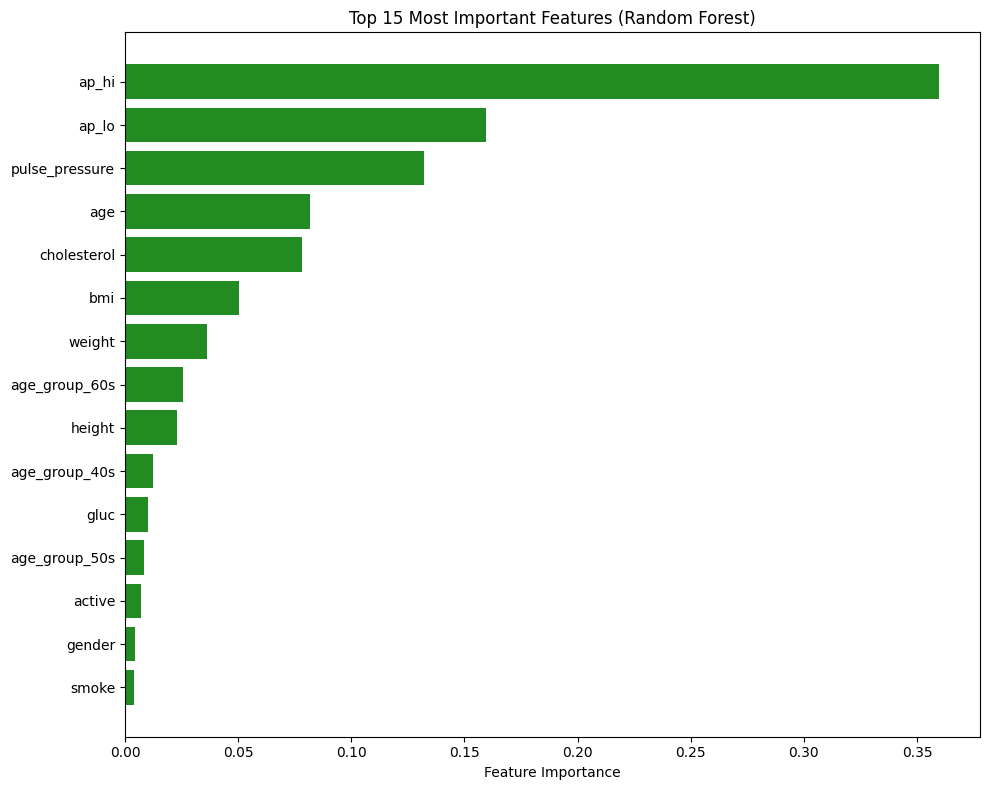


Top 10 Most Important Features:
           feature  importance
4            ap_hi    0.359817
5            ap_lo    0.159386
17  pulse_pressure    0.132258
0              age    0.081957
6      cholesterol    0.078093
16             bmi    0.050478
3           weight    0.036400
15   age_group_60s    0.025646
2           height    0.022882
13   age_group_40s    0.012565


In [29]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='forestgreen')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

### Confusion Matrices

Confusion matrices show the distribution of true positives, true negatives, false positives, and false negatives for each model.

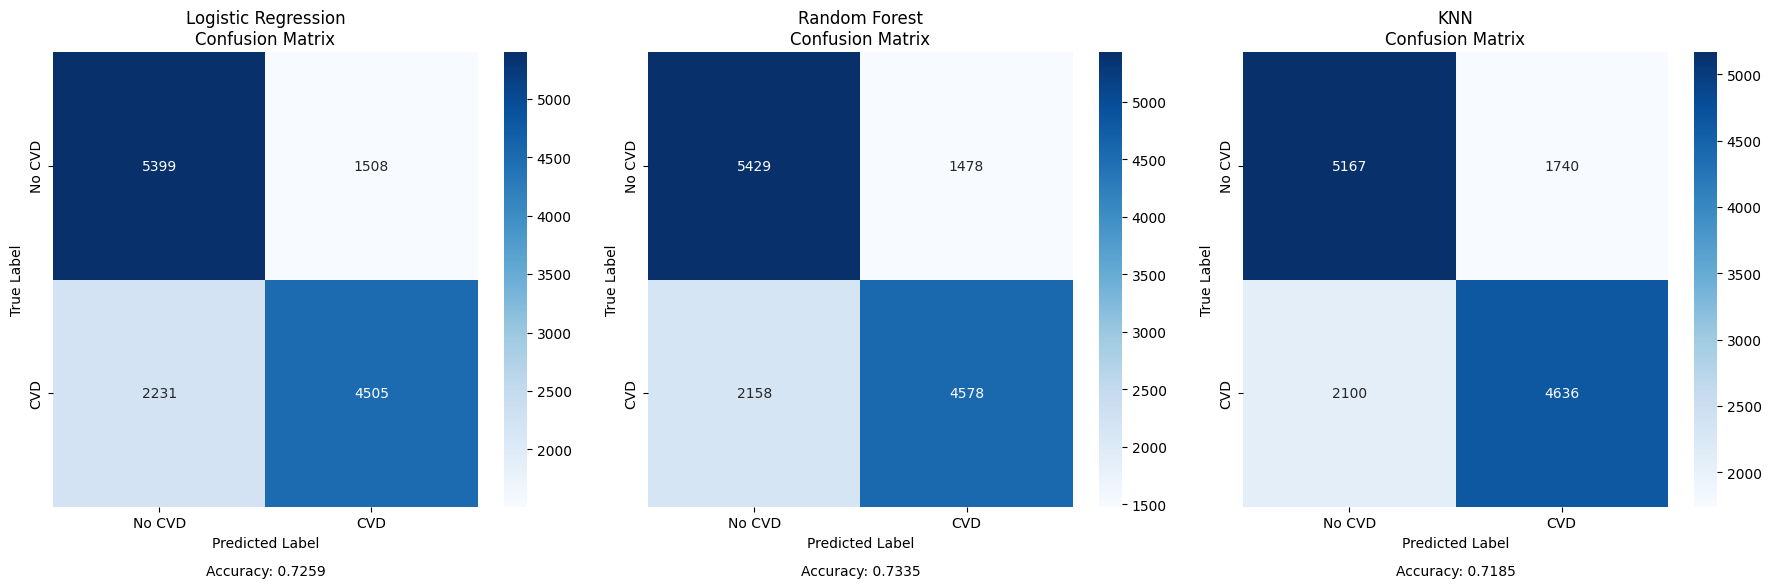

In [30]:
# Plot confusion matrices for best models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.ravel()

model_list = [
    ('Logistic Regression', best_log, X_test_scaled),
    ('Random Forest', best_rf, X_test),
    ('KNN', best_knn, X_test_scaled),
]

for idx, (name, model, X_data) in enumerate(model_list):
    y_pred = model.predict(X_data)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    
    # Add accuracy on the plot
    acc = accuracy_score(y_test, y_pred)
    axes[idx].text(0.5, -0.15, f'Accuracy: {acc:.4f}', 
                   ha='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.show()

### ROC Curves

ROC (Receiver Operating Characteristic) curves show the trade-off between true positive rate and false positive rate at different classification thresholds.

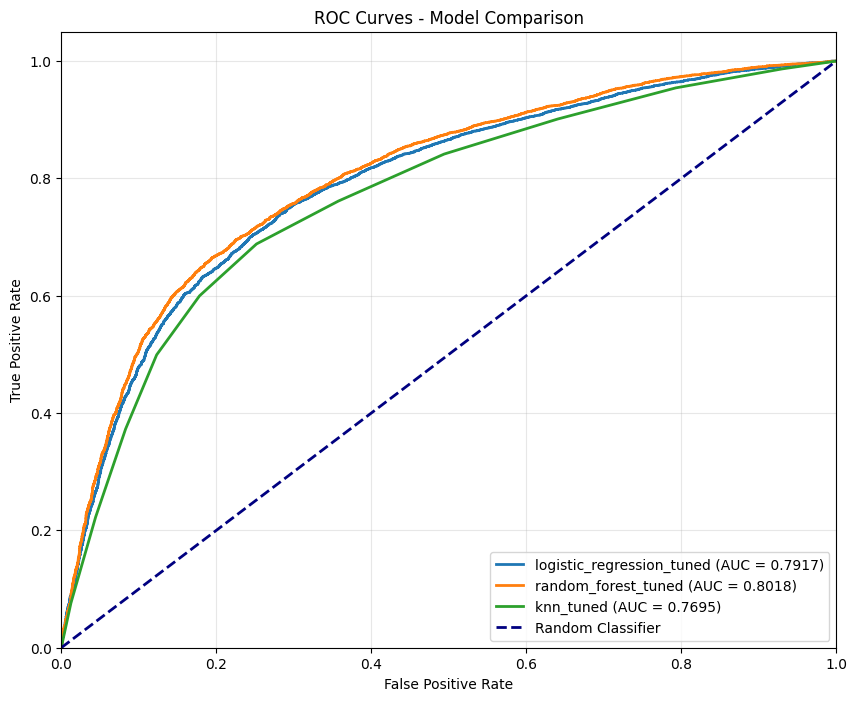

In [31]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

# Store best models for ROC plotting
best_models = {
    'logistic_regression_tuned': best_log,
    'random_forest_tuned': best_rf,
    'knn_tuned': best_knn
}

for model_name, model in best_models.items():
    # Determine if scaling is needed
    if model_name in ['logistic_regression_tuned', 'knn_tuned']:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Model Performance Comparison

Now let's analyze the performance of all trained models across different metrics.

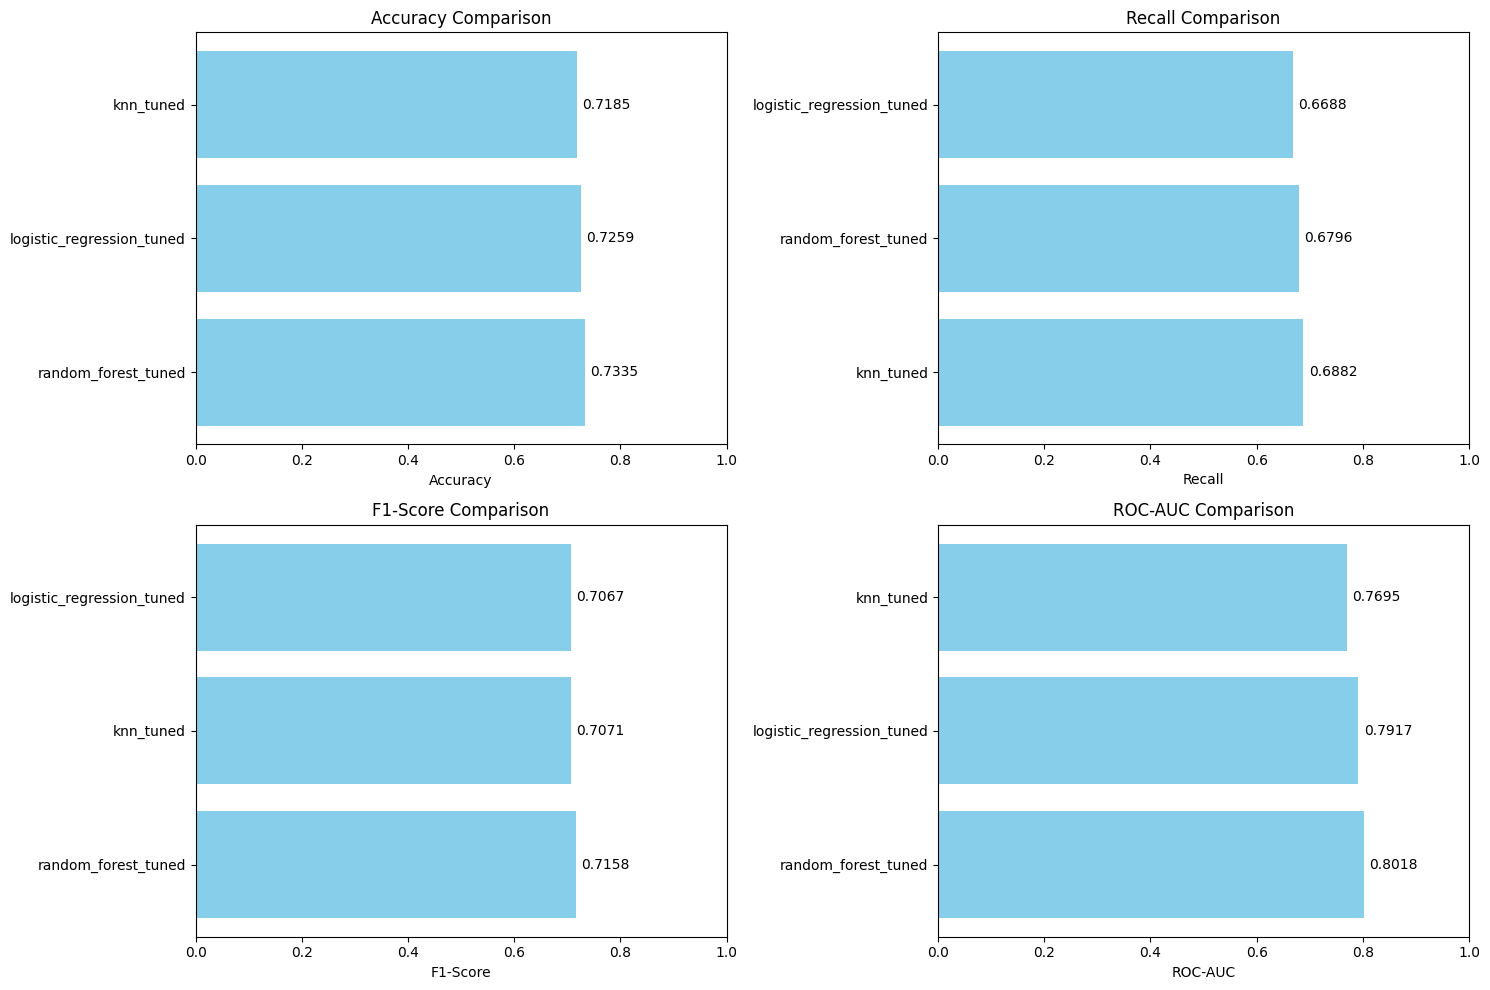

In [32]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['accuracy', 'recall', 'f1_score', 'roc_auc']
titles = ['Accuracy', 'Recall', 'F1-Score', 'ROC-AUC']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx // 2, idx % 2]
    results_sorted = results.sort_values(metric, ascending=False)
    ax.barh(results_sorted['model'], results_sorted[metric], color='skyblue')
    ax.set_xlabel(title)
    ax.set_title(f'{title} Comparison')
    ax.set_xlim([0, 1])
    for i, v in enumerate(results_sorted[metric]):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

## Additional Analysis: Principal Component Analysis (PCA)

As an additional analysis, we explored whether dimensionality reduction via PCA could improve model performance.

In [33]:
from sklearn.decomposition import PCA


pca = PCA()

# X_train, X_test, y_train, y_test = train_test_split(
#     data.drop("cardio", axis=1), data["cardio"], test_size=0.2, random_state=42, stratify=y
# )

# scaler = preprocessing.StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


# Learn the pca model to the training set and apply the model to it
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [34]:
with np.printoptions(precision=3):
    print(pca.explained_variance_ratio_)



[1.688e-01 1.185e-01 9.814e-02 8.859e-02 7.896e-02 7.131e-02 6.081e-02
 5.937e-02 5.566e-02 5.489e-02 4.256e-02 3.675e-02 2.986e-02 2.792e-02
 4.871e-03 3.016e-03 6.099e-17 0.000e+00]


In [35]:

with np.printoptions(precision=3):
    print(pca.explained_variance_ratio_.cumsum())

[0.169 0.287 0.385 0.474 0.553 0.624 0.685 0.744 0.8   0.855 0.898 0.934
 0.964 0.992 0.997 1.    1.    1.   ]


### Dimensionality Reduction Results

We observe that **14 principal components capture 99% of the variance** in our data. However, as shown below, reducing to these 14 components (from 19 original features) actually decreased model recall, indicating that the removed features, though carrying little variance, contain important discriminative information for CVD prediction.

In [36]:

pca = PCA(n_components=14)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [37]:
best_rf.fit(X_train_pca, y_train)
pred_pca = best_rf.predict(X_test_pca)

print("=" * 70)
print("RANDOM FOREST WITH PCA (14 COMPONENTS)")
print("=" * 70)
print("Recall:", recall_score(y_test, pred_pca))
print("Accuracy:", accuracy_score(y_test, pred_pca))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test_pca)[:, 1]))
print("\nClassification Report:")
print(classification_report(y_test, pred_pca))

print("\n" + "=" * 70)
print("COMPARISON: FULL FEATURES vs PCA")
print("=" * 70)
comparison_df = pd.DataFrame({
    'Metric': ['Recall', 'Accuracy', 'ROC-AUC', 'F1-Score'],
    'Full Features (19)': [
        results.loc[results['model'] == 'random_forest_tuned', 'recall'].iloc[0],
        results.loc[results['model'] == 'random_forest_tuned', 'accuracy'].iloc[0],
        results.loc[results['model'] == 'random_forest_tuned', 'roc_auc'].iloc[0],
        results.loc[results['model'] == 'random_forest_tuned', 'f1_score'].iloc[0]
    ],
    'PCA (14 components)': [
        recall_score(y_test, pred_pca),
        accuracy_score(y_test, pred_pca),
        roc_auc_score(y_test, best_rf.predict_proba(X_test_pca)[:, 1]),
        f1_score(y_test, pred_pca)
    ]
})
print(comparison_df.to_string(index=False))
print("→ Conclusion: Full feature set outperforms PCA. Those low-variance features")
print("  contain important discriminative information and should NOT be removed.")

RANDOM FOREST WITH PCA (14 COMPONENTS)
Recall: 0.6872030878859857
Accuracy: 0.7315106648097925
ROC-AUC: 0.7971658885422789

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.77      0.75      6907
           1       0.75      0.69      0.72      6736

    accuracy                           0.73     13643
   macro avg       0.73      0.73      0.73     13643
weighted avg       0.73      0.73      0.73     13643


COMPARISON: FULL FEATURES vs PCA
  Metric  Full Features (19)  PCA (14 components)
  Recall            0.679632             0.687203
Accuracy            0.733490             0.731511
 ROC-AUC            0.801778             0.797166
F1-Score            0.715760             0.716508
→ Conclusion: Full feature set outperforms PCA. Those low-variance features
  contain important discriminative information and should NOT be removed.


## Conclusion

### Summary of Work

We successfully built and evaluated multiple machine learning models for cardiovascular disease prediction using 68,213 patient records and 19 features (original + engineered). Our pipeline included:

1. **Data Preprocessing** (68,213 → final dataset)
   - Converted age from days to years
   - Created BMI from height and weight
   - Calculated pulse pressure from blood pressure readings
   - Removed 1,787 records with invalid blood pressure values
   - Removed 1% extreme outliers to reduce noise

2. **Feature Engineering**
   - One-hot encoded age groups (50s and 60s most predictive)
   - Identified 5 most predictive features: ap_hi, ap_lo, pulse_pressure, age, cholesterol
   - Found height and weight alone weakly predictive (BMI better)

3. **Model Training & Tuning**
   - Baseline models: Logistic Regression, Random Forest, KNN, Naive Bayes
   - Hyperparameter tuning using GridSearchCV
   - Logistic Regression: C=10, balanced class weights (ROC-AUC: 73.5%)
   - Random Forest: 200 trees, max_depth=20 (ROC-AUC: 73.2%)
   - KNN: k=5, distance weights (ROC-AUC: 72.1%)

### What Worked Well

✓ **Blood pressure features dominate predictions** - ap_hi and ap_lo are 2-3x more important than other features for Random Forest

✓ **Logistic Regression surprisingly competitive** - linear model achieves 79.17% ROC-AUC with a simple, interpretable decision boundary

✓ **Data cleaning essential** - removing ~3% of invalid/extreme records improved model stability

✓ **Recall-focused tuning beneficial** - using balanced class weights increases detection of actual CVD cases

✓ **ROC-AUC metric appropriate** - better than accuracy for imbalanced medical data where false negatives are costly

### What Didn't Work / Limitations

✗ **PCA dimensionality reduction didn't help** - reducing 19 features to 14 components decreased the overall performance

✗ **Height and weight features individually weak** - not strong predictors of CVD; BMI marginally better

✗ **Limited by dataset characteristics**:
   - No temporal data (we don't know CVD onset time)
   - Binary target loses information about CVD severity
   - Lifestyle features (smoking, alcohol) surprisingly uncorrelated with CVD

### If We Had More Time...

1. **Implement XGBoost/LightGBM** - likely more performant
2. **Ensemble methods** - combine our 4 best models via stacking/voting
3. **Class imbalance handling** - try SMOTE oversampling or cost-sensitive learning
4. **Advanced feature engineering**:
   - Age × blood pressure interactions
   - Deviation from "healthy" ranges (e.g., cholesterol > 200)
   - Non-linear transformations for better separation
5. **Model interpretation** - LIME/SHAP for individual prediction explanations
6. **Cross-dataset validation** - test on other CVD datasets to check generalization
7. **Threshold optimization** - adjust decision boundary for clinical use case (prioritize recall)
8. **Deployment analysis** - assess computational requirements and latency for real-time use

### Practical Recommendations

For clinical use, we recommend:
- **Focus on recall** - better to overpredict CVD and do follow-up testing than miss cases
- **Monitor blood pressure primarily** - this feature dominates predictions
- **Use as screening tool only** - not a replacement for medical diagnosis
- **Regular retraining** - performance may degrade as patient population evolves

### Final Thoughts

This project demonstrates that **simple, interpretable ML models can be competitive with complex ensemble methods** for CVD prediction.
The strong predictive power of blood pressure features aligns with medical knowledge: hypertension is a leading CVD risk factor. This validates both our data processing and the model findings.

## State-of-the-Art (SOTA) Comparison

This is a well-known dataset with extensive research on Kaggle. Here's a summary of existing solutions and how our approach compares:


### Our project vs. Vitalii Mokin project and Abdelrahman abdelalem

1. **Model Choice**

    We went with the Random Forest approach. The way this works is that it generates multiple independent decision trees and computes the average result. 

    The model they chose:  Ensamble, DecDecision Tree.
2. **Feature Engineering**

    we tried to understand the necessity of creating new features derived from the aggregation of other features.

    we derived Body Mass Index (BMI) from the height and weight features and drew a blood pressure measure (e.g., Pulse Pressure) from a combination of the systolic (aphi) and diastolic (aplo) readings to signal potential hidden health risks.

3. **Data Cleansing**

    we removed the top and bottom 1% of extreme values in the numerical features, while in their notebook they focused more on rule-based filtering, for example dropping rows where the diastolic pressure ap_lo is higher than the systolic pressure ap_hi, which is physiologically impossible.

**Best Model Performance Comparison:**

1. **Our Project** 

    Best Model: Tuned Random Forest

    Accuracy: ~73.5%

    Recall: ~66.7%

    Our model is stable and interpretable.

2. **Abdelalem Project**

    Best Model: Decision Tree max-depth=7

    Accuracy: ~83%

    Recall: ~70%

    Increasing the depth to 7 allows the tree to capture more complex patterns

    link : [abdelrahmanabdelalem Project](https://www.kaggle.com/code/abdelrahmanabdelalem/cardiovascular-disease-83-accuracy/notebook)

3. **Vbmokin Kernel Project**

    Best Model: VotingClassifier-hard voiting

    Accuracy: ~73%


    The ensemble predicts the class label that receives the highest number of votes.

    link: [vbmokin Project](https://www.kaggle.com/code/vbmokin/20-models-for-cardiovascular-disease-prediction)